In [33]:
# Cell 0: (run in a terminal cell) Install required packages if you don't have them
# Run once in notebook (preface with ! in a Jupyter cell) or install in your environment.
!pip install lightgbm xgboost optuna matplotlib seaborn scikit-learn pandas joblib statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.4 MB/s eta 0:00:00a 0:00:01


In [34]:
# Cell 1: Imports & basic settings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')
plt.style.use('classic')
%matplotlib inline


In [35]:
# Cell 2: Load dataset (update path if necessary)
DATA_PATH = "delhi_aqi.csv"   # <-- put the CSV here
df = pd.read_csv(DATA_PATH, parse_dates=True, infer_datetime_format=True)
print("Raw shape:", df.shape)
df.head(5)


Raw shape: (18776, 9)


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2020-11-25 01:00:00,2616.88,2.18,70.60,13.59,38.62,364.61,411.73,28.63
1,2020-11-25 02:00:00,3631.59,23.25,89.11,0.33,54.36,420.96,486.21,41.04
2,2020-11-25 03:00:00,4539.49,52.75,100.08,1.11,68.67,463.68,541.95,49.14
3,2020-11-25 04:00:00,4539.49,50.96,111.04,6.44,78.20,454.81,534.00,48.13
4,2020-11-25 05:00:00,4379.27,42.92,117.90,17.17,87.74,448.14,529.19,46.61


In [36]:
# Cell 3: Inspect columns and find datetime + pollutant columns
print("Columns:", df.columns.tolist())
# Try to find datetime-like column
possible_dt = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower() or 'datetime' in c.lower()]
print("Possible datetime columns:", possible_dt)
# If none found, try to guess the first column
if len(possible_dt)==0:
    # attempt to interpret first column as datetime
    df.columns = [c.strip() for c in df.columns]
    df.rename(columns={df.columns[0]:'datetime'}, inplace=True)
    possible_dt = ['datetime']
# parse the chosen datetime column
dt_col = possible_dt[0]
df[dt_col] = pd.to_datetime(df[dt_col], errors='coerce')
df = df.dropna(subset=[dt_col]).sort_values(dt_col).reset_index(drop=True)
df.rename(columns={dt_col:'datetime'}, inplace=True)
print("Using datetime column:", 'datetime')
print("Date range:", df['datetime'].min(), "to", df['datetime'].max())


Columns: ['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
Possible datetime columns: ['date']
Using datetime column: datetime
Date range: 2020-11-25 01:00:00 to 2023-01-24 08:00:00


In [37]:
# Cell 4: Select core pollutant & weather columns (adjust names if dataset differs)
# Common column names in this dataset: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'Temperature', 'Humidity', 'Wind Speed', 'Wind Direction', 'Pressure']
cols = df.columns.tolist()
# heuristics to pick pollutant and weather columns
pollutants = [c for c in cols if any(k in c.lower() for k in ['pm2.5','pm2_5','pm2','pm 2.5','pm25','pm10'])]
pollutants += [c for c in cols if any(k in c.lower() for k in ['no2','so2','o3','co','nox','no'])]
pollutants = list(dict.fromkeys(pollutants))  # unique preserve order
weather_cols = [c for c in cols if any(k in c.lower() for k in ['temp','temperature','humid','wind','pressure','rain','rainfall'])]
print("Detected pollutants:", pollutants)
print("Detected weather cols:", weather_cols)
# If dataset already contains AQI, we'll use it; else we will use PM2.5 as proxy or compute AQI if you want.
has_aqi = any('aqi' in c.lower() for c in cols)
print("Contains AQI column:", has_aqi)


Detected pollutants: ['pm2_5', 'pm10', 'co', 'no', 'no2', 'o3', 'so2']
Detected weather cols: []
Contains AQI column: False


After cleaning shape: (18776, 12)


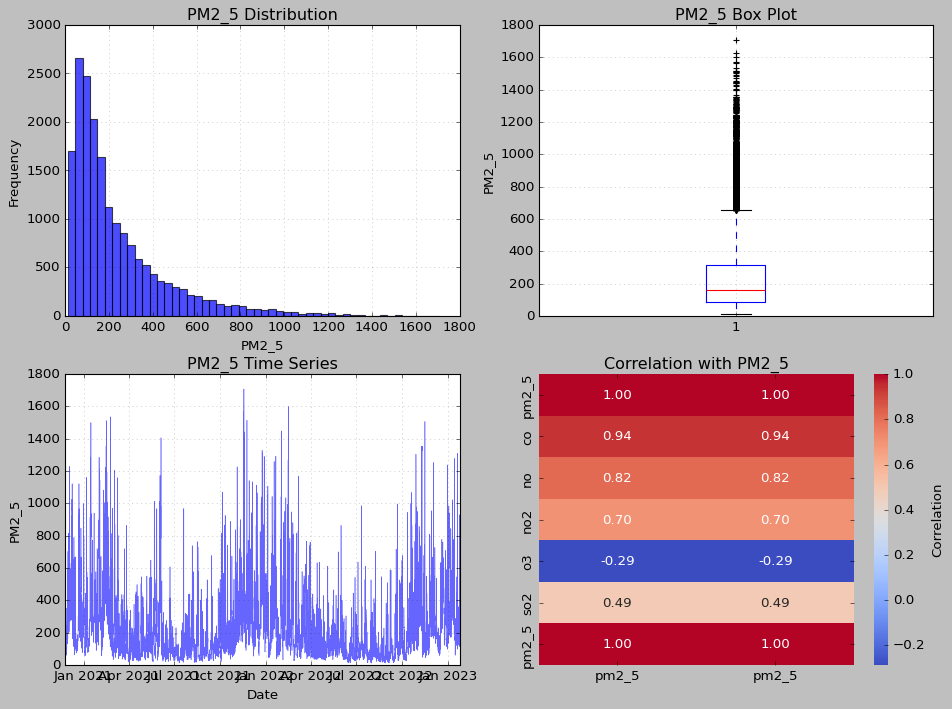

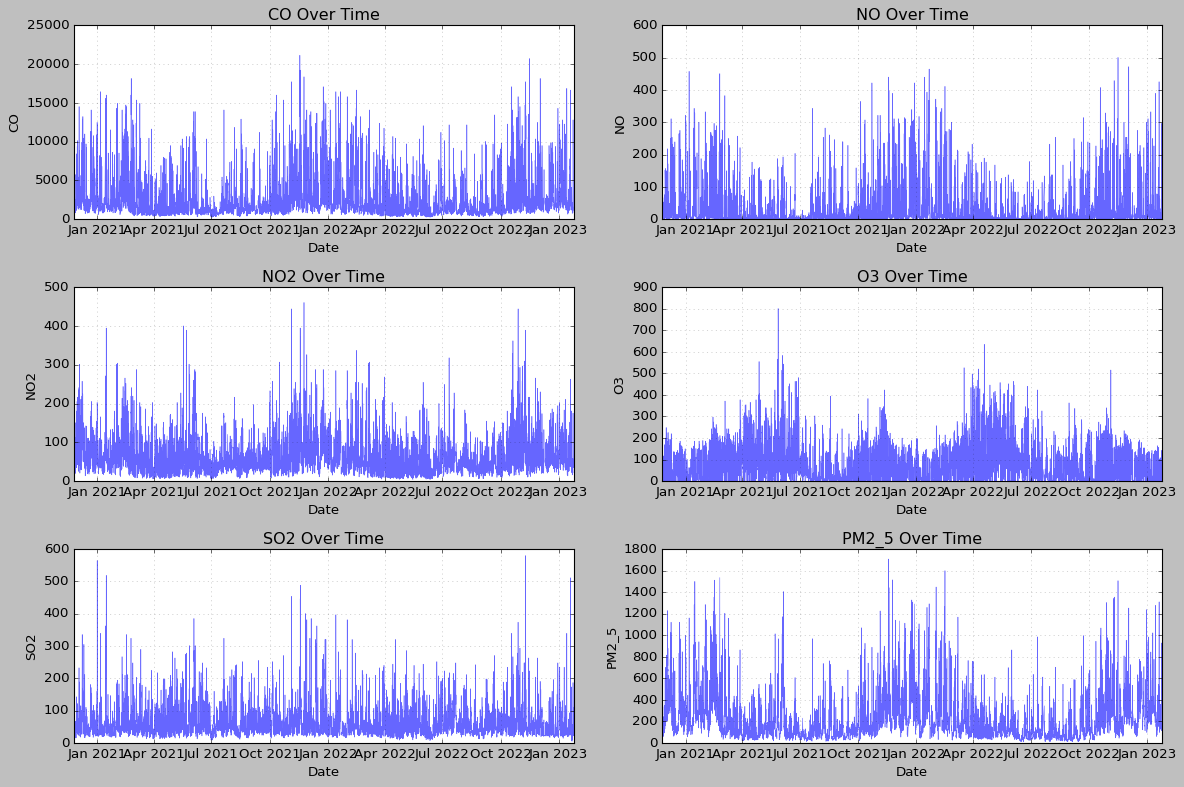

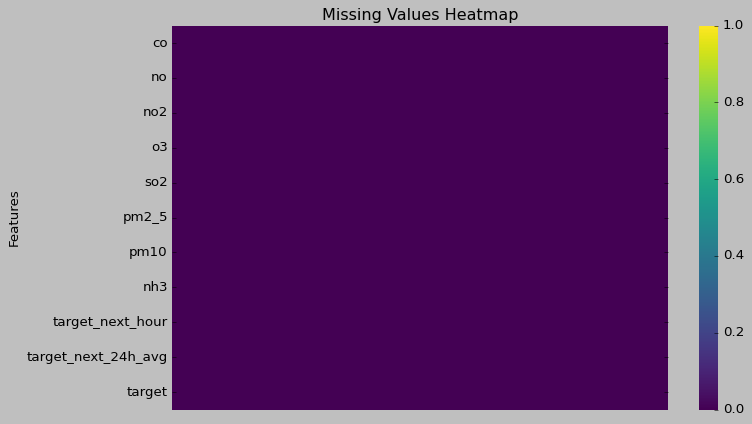

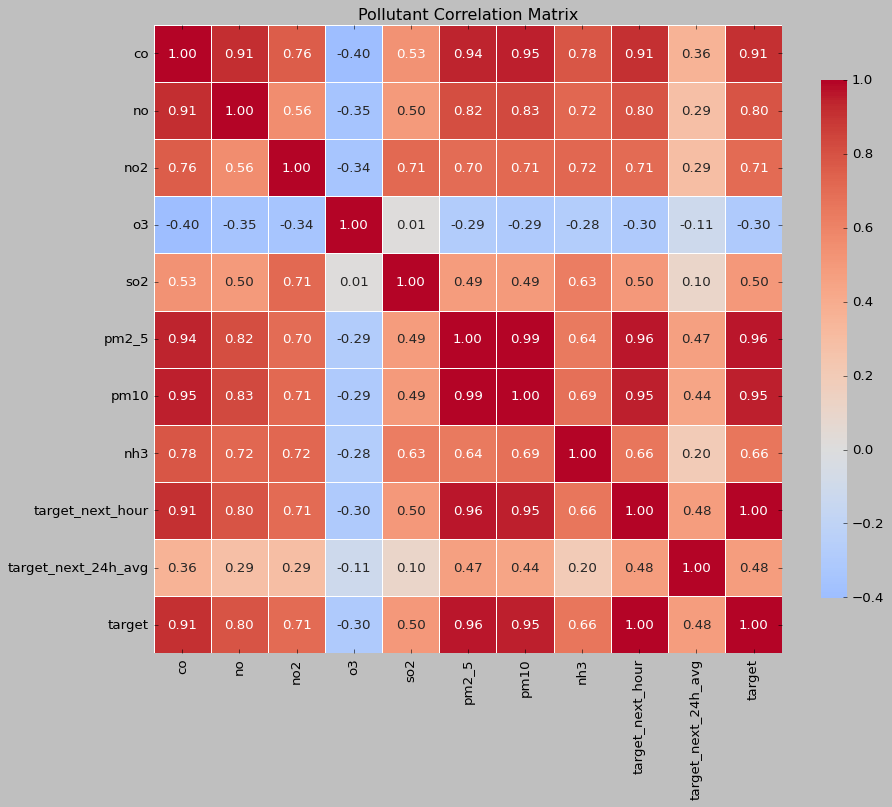

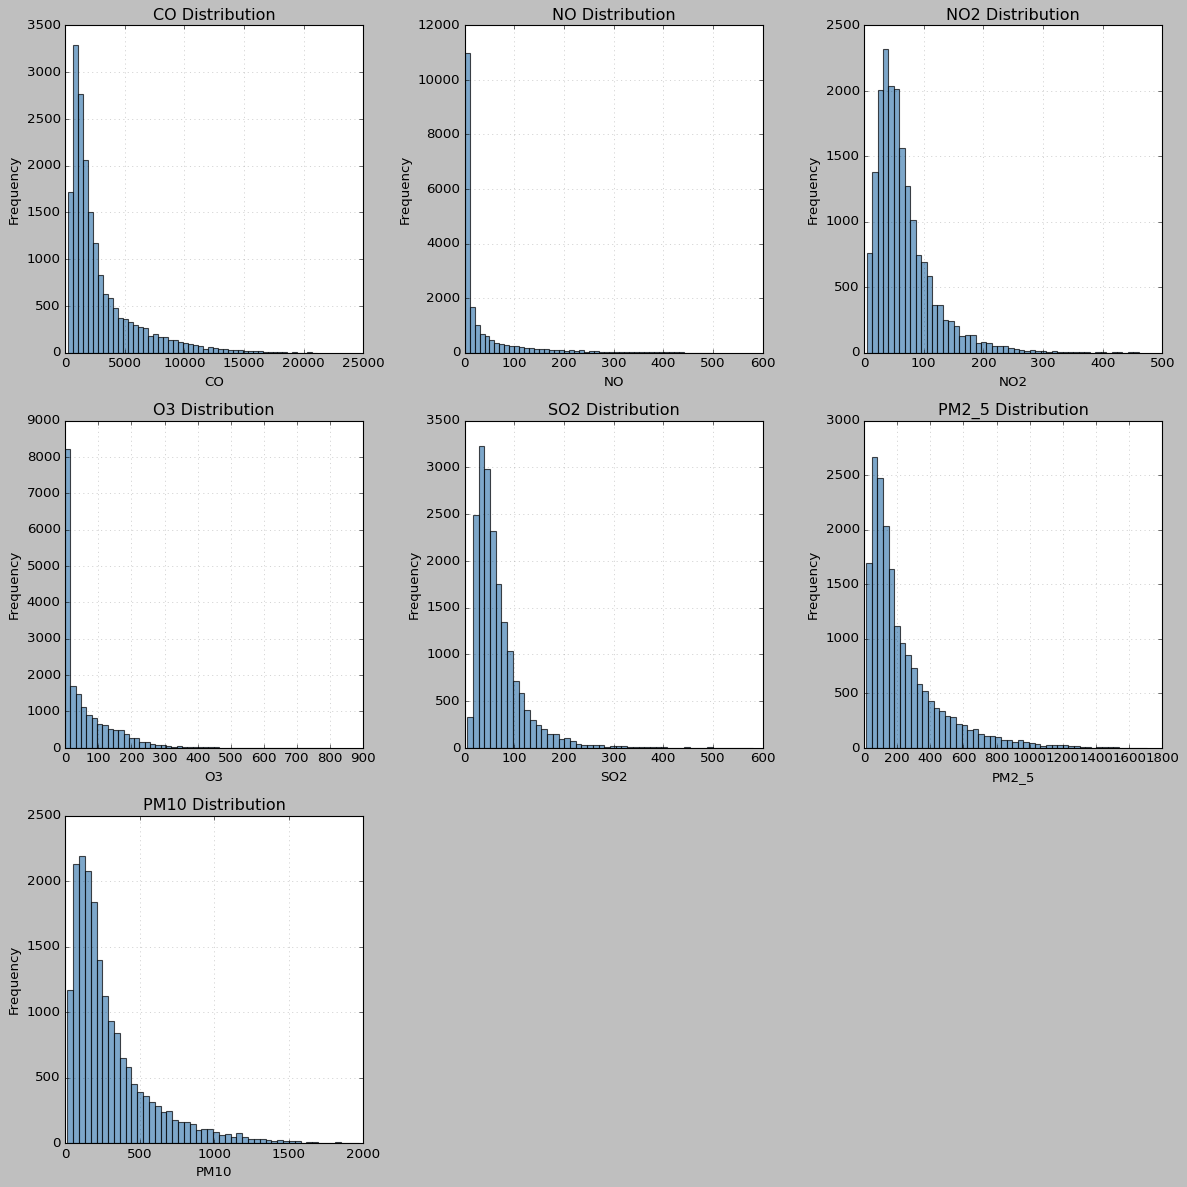

In [40]:
# Cell 5: Basic cleaning and unify column names (lowercase, strip)
df.columns = [c.strip().replace(' ', '_') for c in df.columns]
df.rename(columns={c:c.lower() for c in df.columns}, inplace=True)
# ensure datetime column present and set timezone-naive
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
# Optionally resample to hourly if there are sub-hourly timestamps
# We'll convert to hourly floor to be consistent
df['datetime'] = df['datetime'].dt.floor('H')
# remove duplicates
df = df.drop_duplicates(subset=['datetime'])
print("After cleaning shape:", df.shape)

# Visualization: Time series of all pollutants
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
pollutants_to_plot = [c for c in df.columns if c not in ['datetime'] and df[c].dtype in ['float64', 'int64']][:6]
for idx, col in enumerate(pollutants_to_plot):
    ax = axes[idx // 2, idx % 2]
    ax.plot(df['datetime'], df[col], alpha=0.6, linewidth=0.5)
    ax.set_title(f'{col.upper()} Over Time')
    ax.set_xlabel('Date')
    ax.set_ylabel(col.upper())
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization: Missing values heatmap
if df.select_dtypes(include=['float64', 'int64']).isna().sum().sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_data = df.select_dtypes(include=['float64', 'int64']).isna()
    sns.heatmap(missing_data.T, cbar=True, yticklabels=True, xticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.ylabel('Features')
    plt.show()

# Visualization: Correlation matrix for all pollutants
numeric_cols = [c for c in df.columns if c != 'datetime' and df[c].dtype in ['float64', 'int64']]
if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Pollutant Correlation Matrix')
    plt.tight_layout()
    plt.show()

# Visualization: Distribution of each pollutant
pollutant_cols = [c for c in numeric_cols if any(k in c.lower() for k in ['pm2','pm10','no2','so2','o3','co','no'])]
n_polls = len(pollutant_cols)
if n_polls > 0:
    n_cols = 3
    n_rows = (n_polls + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_polls > 1 else [axes]
    for idx, col in enumerate(pollutant_cols):
        if idx < len(axes):
            axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_title(f'{col.upper()} Distribution')
            axes[idx].set_xlabel(col.upper())
            axes[idx].set_ylabel('Frequency')
            axes[idx].grid(True, alpha=0.3)
    for idx in range(n_polls, len(axes)):
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()


Using target column: pm2_5
Rows with non-null target: 18775 out of 18776


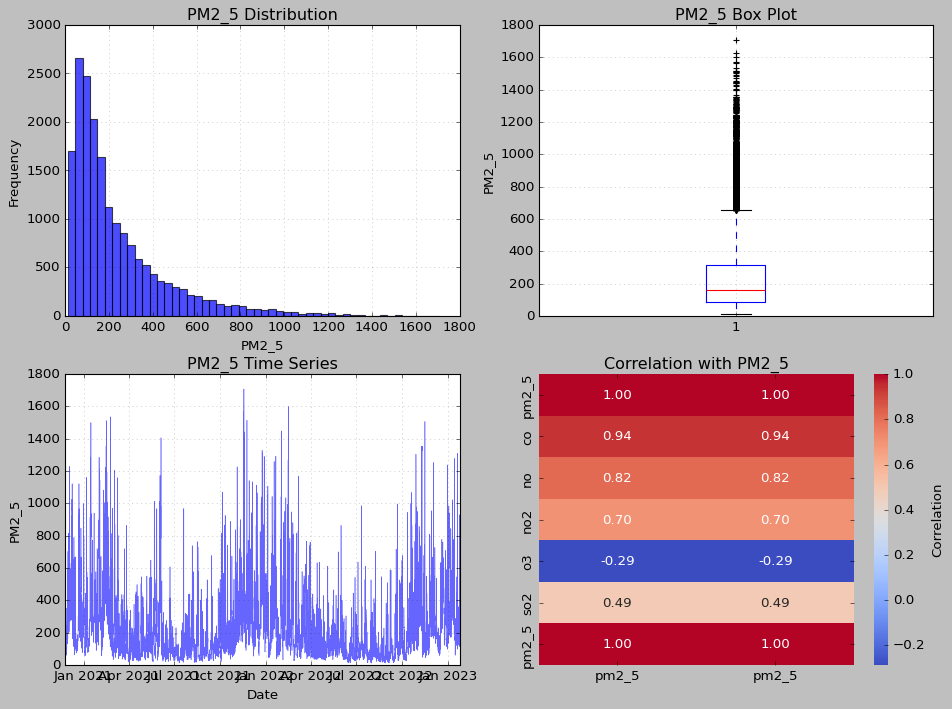

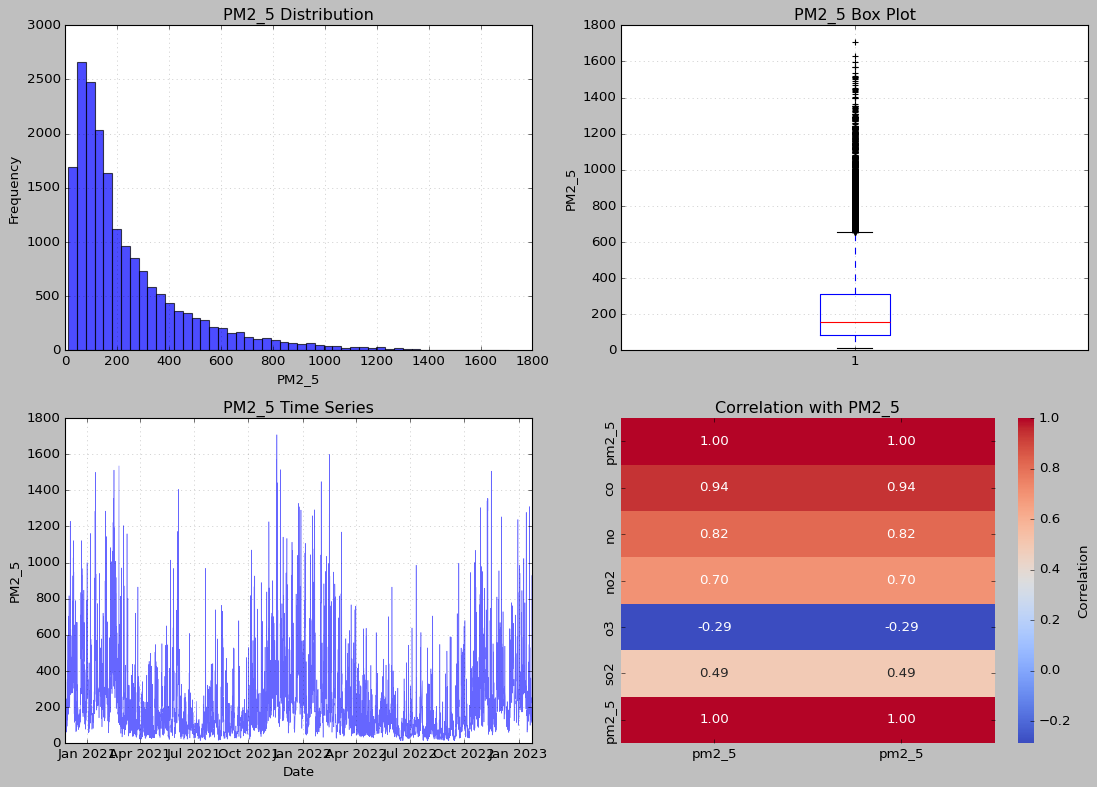

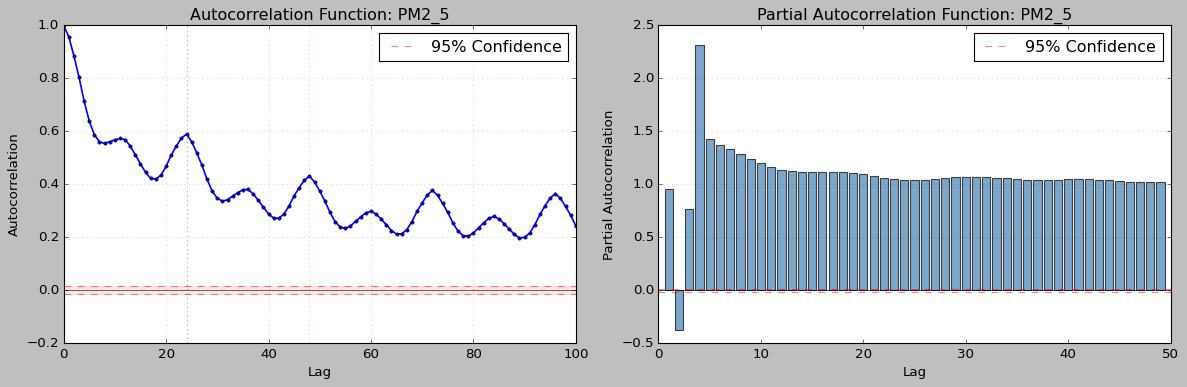

In [42]:
# Cell 6: Choose target - next hour AQI (if 'aqi' exists) else next hour PM2.5
if has_aqi:
    # find the aqi column name
    aqi_col = [c for c in df.columns if 'aqi' in c][0]
    target_col = aqi_col
else:
    # try to find PM2.5 column
    pm25_candidates = [c for c in df.columns if 'pm2' in c]
    if len(pm25_candidates)==0:
        raise ValueError("No AQI or PM2.5 column found. Please check the dataset column names.")
    target_col = pm25_candidates[0]
print("Using target column:", target_col)

# create next-hour target and next-24h average target
df = df.sort_values('datetime').reset_index(drop=True)
df['target_next_hour'] = df[target_col].shift(-1)
df['target_next_24h_avg'] = df[target_col].shift(-24).rolling(window=24, min_periods=1).mean().shift(-23)
# choose which to model (default: next-hour)
df['target'] = df['target_next_hour']
print("Rows with non-null target:", df['target'].notna().sum(), "out of", len(df))

# Visualization: Target distribution and statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(df['target'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title(f'{target_col.upper()} Distribution')
axes[0, 0].set_xlabel(target_col.upper())
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot(df['target'].dropna())
axes[0, 1].set_title(f'{target_col.upper()} Box Plot')
axes[0, 1].set_ylabel(target_col.upper())
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df['datetime'], df[target_col], alpha=0.6, linewidth=0.5)
axes[1, 0].set_title(f'{target_col.upper()} Time Series')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel(target_col.upper())
axes[1, 0].grid(True, alpha=0.3)

pollutant_cols = [c for c in df.columns if c not in ['datetime', 'target', 'target_next_hour', 'target_next_24h_avg'] and df[c].dtype in ['float64', 'int64']][:6]
if len(pollutant_cols) > 0:
    corr_data = df[[target_col] + pollutant_cols].corr()
    sns.heatmap(corr_data[[target_col]], annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
    axes[1, 1].set_title(f'Correlation with {target_col.upper()}')

# Additional visualization: Pair plot for top correlated pollutants
if len(pollutant_cols) >= 3:
    corr_series = corr_data[target_col].squeeze()
    if isinstance(corr_series, pd.Series):
        top_pollutants = corr_series.abs().sort_values(ascending=False).head(4).index.tolist()
        if target_col in top_pollutants:
            top_pollutants.remove(target_col)
        if len(top_pollutants) >= 3:
            top_pollutants = top_pollutants[:3] + [target_col]
            pair_data = df[top_pollutants].dropna().sample(min(2000, len(df)))
            if len(pair_data) > 0:
                fig = plt.figure(figsize=(12, 10))
                g = sns.pairplot(pair_data, diag_kind='kde', corner=True)
                g.fig.suptitle('Pair Plot: Top Correlated Pollutants with Target', y=1.02)
                plt.show()

plt.tight_layout()
plt.show()

# Additional visualization: Autocorrelation analysis
from statsmodels.tsa.stattools import acf
import warnings
warnings.filterwarnings('ignore')

target_values = df[target_col].dropna()
if len(target_values) > 100:
    max_lags = min(100, len(target_values) // 4)
    autocorr = acf(target_values, nlags=max_lags, fft=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(range(len(autocorr)), autocorr, marker='o', markersize=3, linewidth=1.5)
    axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0].axhline(y=1.96/np.sqrt(len(target_values)), color='r', linestyle='--', alpha=0.5, label='95% Confidence')
    axes[0].axhline(y=-1.96/np.sqrt(len(target_values)), color='r', linestyle='--', alpha=0.5)
    axes[0].fill_between(range(len(autocorr)), -1.96/np.sqrt(len(target_values)), 
                         1.96/np.sqrt(len(target_values)), alpha=0.1, color='red')
    axes[0].set_title(f'Autocorrelation Function: {target_col.upper()}')
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('Autocorrelation')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    lag_24_autocorr = autocorr[24] if len(autocorr) > 24 else None
    lag_48_autocorr = autocorr[48] if len(autocorr) > 48 else None
    axes[0].axvline(x=24, color='green', linestyle=':', alpha=0.5, label='24h lag')
    if lag_48_autocorr is not None:
        axes[0].axvline(x=48, color='orange', linestyle=':', alpha=0.5, label='48h lag')
    
    partial_autocorr = []
    for lag in range(1, min(50, len(autocorr))):
        if lag == 1:
            partial_autocorr.append(autocorr[1])
        else:
            numerator = autocorr[lag]
            for j in range(1, lag):
                numerator -= partial_autocorr[j-1] * autocorr[lag - j]
            denominator = 1
            for j in range(1, lag):
                denominator -= partial_autocorr[j-1] * autocorr[j]
            if denominator != 0:
                partial_autocorr.append(numerator / denominator)
            else:
                partial_autocorr.append(0)
    
    if len(partial_autocorr) > 0:
        axes[1].bar(range(1, len(partial_autocorr)+1), partial_autocorr, alpha=0.7, color='steelblue')
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axes[1].axhline(y=1.96/np.sqrt(len(target_values)), color='r', linestyle='--', alpha=0.5, label='95% Confidence')
        axes[1].axhline(y=-1.96/np.sqrt(len(target_values)), color='r', linestyle='--', alpha=0.5)
        axes[1].set_title(f'Partial Autocorrelation Function: {target_col.upper()}')
        axes[1].set_xlabel('Lag')
        axes[1].set_ylabel('Partial Autocorrelation')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


In [ ]:
# Cell 7: Simple missing value fill (short version)

# make sure datetime is sorted
df = df.sort_values('datetime')

# pick numeric columns except target
num_cols = df.select_dtypes(include='number').columns.tolist()
fill_cols = [c for c in num_cols if 'target' not in c]

# simple linear interpolation + ffill + bfill (no datetime index needed)
df[fill_cols] = df[fill_cols].interpolate().ffill().bfill()

print("Missing values remaining:", df[fill_cols].isna().sum().sum())


Missing values remaining: 0


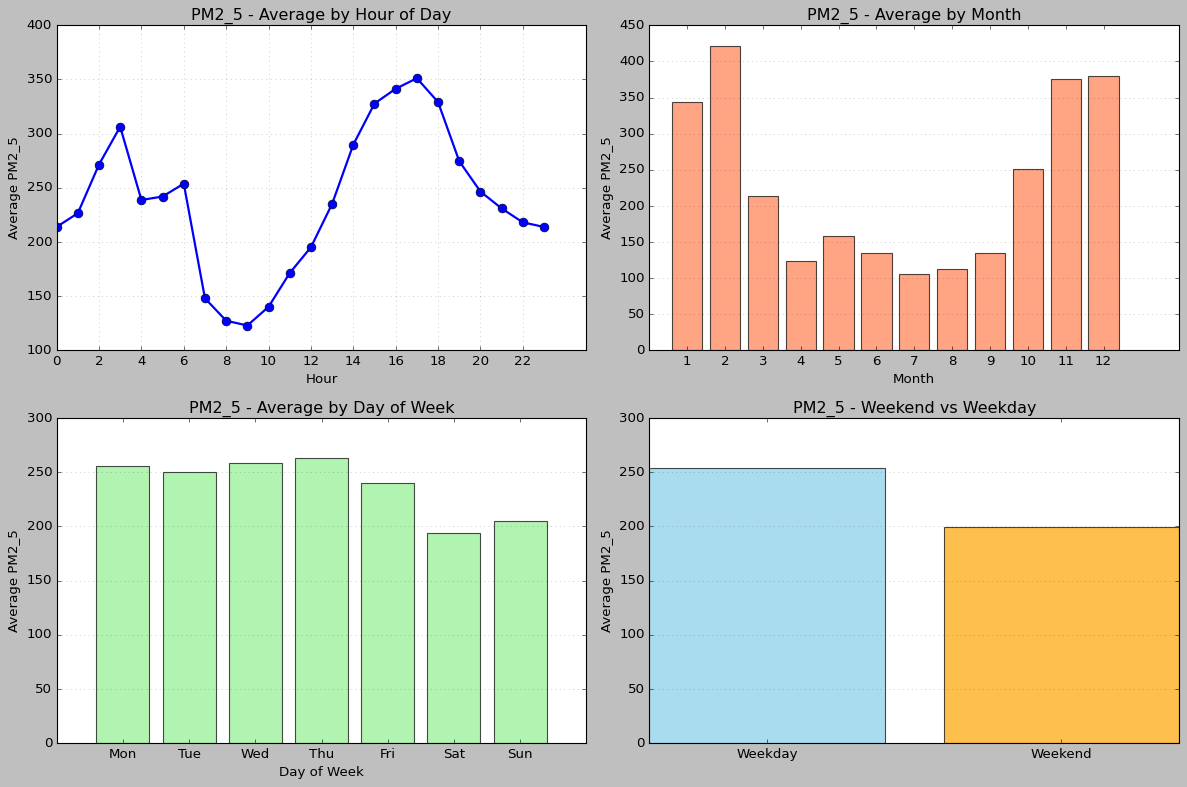

In [43]:
# Cell 8: Feature engineering - time features and seasonal
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['weekday'] = df['datetime'].dt.weekday
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
def season_from_month(m):
    if m in [12,1,2]: return 'winter'
    if m in [3,4,5]: return 'spring'
    if m in [6,7,8]: return 'monsoon'
    return 'autumn'
df['season'] = df['month'].apply(season_from_month)
df = pd.get_dummies(df, columns=['season'], drop_first=True)
# peak hour
df['is_peak_hour'] = df['hour'].isin([7,8,9,17,18,19]).astype(int)

# Visualization: Time-based patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Hourly average of target
hourly_avg = df.groupby('hour')[target_col].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=8)
axes[0, 0].set_title(f'{target_col.upper()} - Average by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel(f'Average {target_col.upper()}')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# Monthly average of target
monthly_avg = df.groupby('month')[target_col].mean()
axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='coral', alpha=0.7)
axes[0, 1].set_title(f'{target_col.upper()} - Average by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel(f'Average {target_col.upper()}')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_xticks(range(1, 13))

# Weekday average
weekday_avg = df.groupby('weekday')[target_col].mean()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(range(7), weekday_avg.values, color='lightgreen', alpha=0.7)
axes[1, 0].set_title(f'{target_col.upper()} - Average by Day of Week')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel(f'Average {target_col.upper()}')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(weekday_names)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Weekend vs Weekday comparison
weekend_comparison = df.groupby('is_weekend')[target_col].mean()
axes[1, 1].bar(['Weekday', 'Weekend'], weekend_comparison.values, color=['skyblue', 'orange'], alpha=0.7)
axes[1, 1].set_title(f'{target_col.upper()} - Weekend vs Weekday')
axes[1, 1].set_ylabel(f'Average {target_col.upper()}')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [ ]:
# Cell 9: Wind encoding - sine/cosine (if wind direction exists)
wind_deg_cols = [c for c in df.columns if 'wind_direction' in c or 'wind_deg' in c or 'winddirection' in c or 'wind_dir' in c]
if wind_deg_cols:
    wd = wind_deg_cols[0]
    df[wd] = df[wd].fillna(0)
    df['wind_rad'] = np.deg2rad(df[wd])
    df['wind_sin'] = np.sin(df['wind_rad'])
    df['wind_cos'] = np.cos(df['wind_rad'])
    df.drop(columns=['wind_rad'], inplace=True)
    print("Added wind_sin, wind_cos from", wd)
else:
    print("No wind direction column found; skipping circular encoding.")


No wind direction column found; skipping circular encoding.


Using pollutant columns for lags: ['co', 'no2', 'o3', 'so2', 'pm2_5', 'pm10']


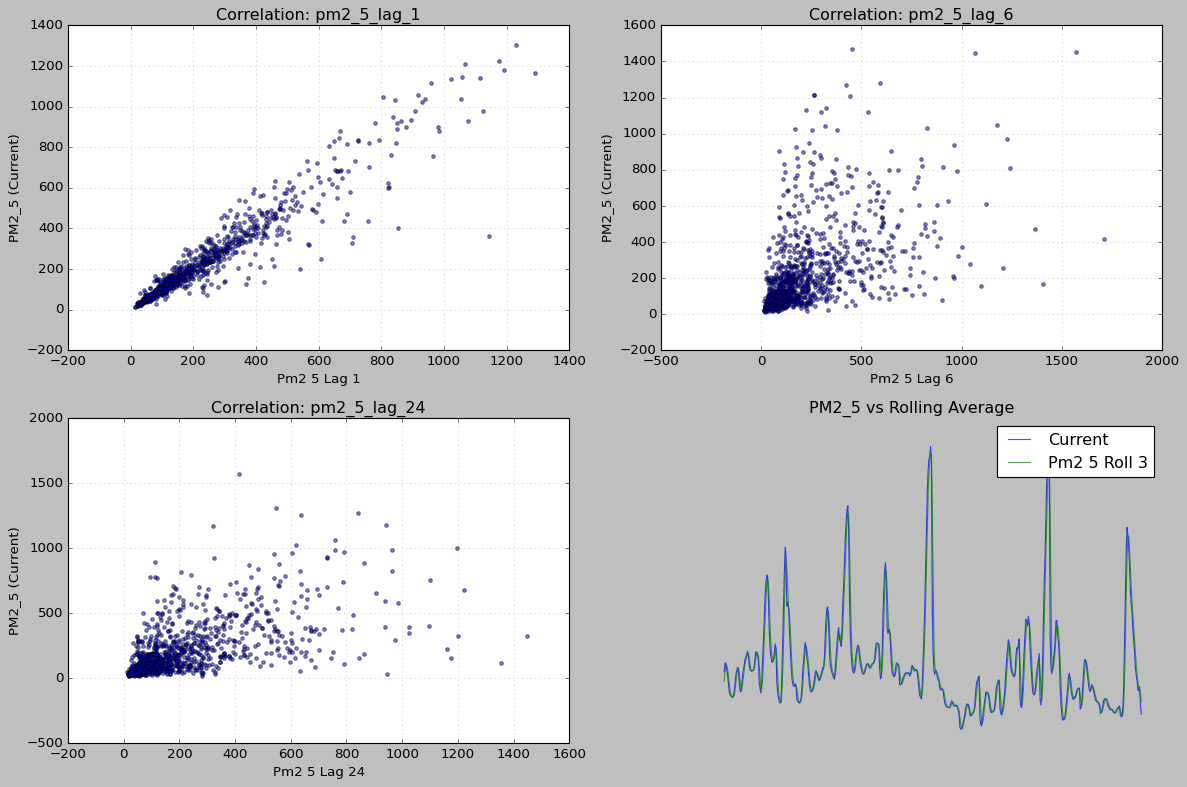

In [44]:
# Cell 10: Lag & rolling features for pollutants (hourly and daily)
# choose pollutant columns present (common names)
polls = [c for c in df.columns if any(x in c for x in ['pm2','pm10','no2','so2','o3','co'])]
# ensure unique and present
polls = [p for p in polls if p in df.columns]
print("Using pollutant columns for lags:", polls)
lags_hours = [1,3,6,12,24]
for p in polls:
    for h in lags_hours:
        df[f'{p}_lag_{h}'] = df[p].shift(h)
    df[f'{p}_roll_3'] = df[p].rolling(window=3, min_periods=1).mean()
    df[f'{p}_roll_24'] = df[p].rolling(window=24, min_periods=1).mean()
    df[f'{p}_diff_1'] = df[p] - df[p].shift(1)
# ratio feature if pm2.5 and pm10 exist
if any('pm2' in p for p in polls) and any('pm10' in p for p in polls):
    pm25_col = [p for p in polls if 'pm2' in p][0]
    pm10_col = [p for p in polls if 'pm10' in p][0]
    df['pm25_pm10_ratio'] = df[pm25_col] / df[pm10_col].replace(0, np.nan)

# Visualization: Lag feature effects
if target_col in polls:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    lag_cols = [f'{target_col}_lag_1', f'{target_col}_lag_6', f'{target_col}_lag_24']
    available_lags = [c for c in lag_cols if c in df.columns]
    
    if len(available_lags) > 0:
        for idx, lag_col in enumerate(available_lags[:3]):
            ax = axes[idx // 2, idx % 2]
            sample_data = df[[target_col, lag_col]].dropna().sample(min(1000, len(df)))
            ax.scatter(sample_data[lag_col], sample_data[target_col], alpha=0.5, s=10)
            ax.set_xlabel(lag_col.replace('_', ' ').title())
            ax.set_ylabel(f'{target_col.upper()} (Current)')
            ax.set_title(f'Correlation: {lag_col}')
            ax.grid(True, alpha=0.3)
        
        if len(available_lags) < 4:
            axes[1, 1].axis('off')
        
        roll_cols = [f'{target_col}_roll_3', f'{target_col}_roll_24']
        available_rolls = [c for c in roll_cols if c in df.columns]
        
        if len(available_rolls) > 0 and len(available_lags) < 4:
            roll_col = available_rolls[0]
            sample_data = df[[target_col, roll_col]].dropna().tail(500)
            axes[1, 1].plot(sample_data.index, sample_data[target_col], label='Current', alpha=0.7)
            axes[1, 1].plot(sample_data.index, sample_data[roll_col], label=roll_col.replace('_', ' ').title(), alpha=0.7)
            axes[1, 1].set_xlabel('Time Index')
            axes[1, 1].set_ylabel(target_col.upper())
            axes[1, 1].set_title(f'{target_col.upper()} vs Rolling Average')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [ ]:
# Cell 11: Optional: Add holiday/diwali/crop-burning indicators (simple)
# We'll mark Oct-Nov as crop-burning; add placeholder for major festival DIWALI (find exact dates as needed)
df['is_crop_burning_season'] = df['month'].isin([10,11]).astype(int)
# If you have a holiday list CSV, merge to set is_holiday
df['is_holiday'] = 0


In [ ]:
# Cell 12: Prepare final modeling dataset (drop rows with NaN targets)
df_model = df.dropna(subset=['target']).copy()
# Drop columns we don't want as features
drop_cols = ['datetime', 'target_next_hour', 'target_next_24h_avg', 'target']
# drop raw textual columns if any
drop_cols += [c for c in df_model.columns if df_model[c].dtype == object]
X = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])
y = df_model['target'].copy()
# keep only numeric features
X = X.select_dtypes(include=[np.number]).fillna(0)
print("Model rows:", X.shape[0], "features:", X.shape[1])


Model rows: 18775 features: 65


In [ ]:
# Cell 13: Train/test split - time-based (last 15% as test)
split_idx = int(len(X) * 0.85)   # change split fraction as needed
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print("Train size:", X_train.shape, "Test size:", X_test.shape)

# Visualization: Train/Test split visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

train_datetime = df_model['datetime'].iloc[:split_idx]
test_datetime = df_model['datetime'].iloc[split_idx:]
train_target = y_train
test_target = y_test

axes[0].plot(train_datetime, train_target, label='Train', alpha=0.6, linewidth=0.5, color='blue')
axes[0].plot(test_datetime, test_target, label='Test', alpha=0.6, linewidth=0.5, color='red')
axes[0].axvline(x=test_datetime.iloc[0], color='green', linestyle='--', linewidth=2, label='Split Point')
axes[0].set_title('Train/Test Split - Time Series')
axes[0].set_xlabel('Date')
axes[0].set_ylabel(f'{target_col.upper()}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(train_target, bins=50, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1].hist(test_target, bins=50, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1].set_title('Train/Test Target Distribution')
axes[1].set_xlabel(f'{target_col.upper()}')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


Train size: (15958, 65) Test size: (2817, 65)


In [ ]:
# Cell 14: Utility: evaluation metrics
def eval_metrics(y_true, y_pred):
    return {
        'rmse': mean_squared_error(y_true, y_pred, squared=False),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }


In [ ]:
# Cell 15 —  RandomForest training + metrics

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

# simple metric calculations (RMSE, MAE, R2)
rf_rmse = (( (y_test - rf_preds) ** 2 ).mean()) ** 0.5
rf_mae  = (y_test - rf_preds).abs().mean()
rf_r2   = r2_score(y_test, rf_preds)

print("RandomForest Results:")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R² :", rf_r2)


RandomForest Results:
RMSE: 41.961150115867596
MAE: 23.968759293368937
R² : 0.9666422424751454


In [ ]:
# Cell 16 — LightGBM Final Model
from lightgbm import LGBMRegressor
import joblib, numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_params = globals().get('best_params', {'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8})
final_model = LGBMRegressor(**best_params, n_estimators=500, objective='regression', random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

# evaluate
preds = final_model.predict(X_test)
lgb_rmse = np.sqrt(mean_squared_error(y_test, preds))
lgb_mae  = mean_absolute_error(y_test, preds)
lgb_r2   = r2_score(y_test, preds)
print("LightGBM test results -> RMSE:", lgb_rmse, "MAE:", lgb_mae, "R2:", lgb_r2)

# save
os.makedirs('models', exist_ok=True)
joblib.dump(final_model, 'models/lightgbm_best.joblib')
print("Saved to models/lightgbm_best.joblib")


LightGBM test results -> RMSE: 32.490277769145905 MAE: 18.422863514662907 R2: 0.9800009701104951
Saved to models/lightgbm_best.joblib


LightGBM Evaluation:
RMSE: 32.490277769145905
MAE : 18.422863514662907
R²  : 0.9800009701104951


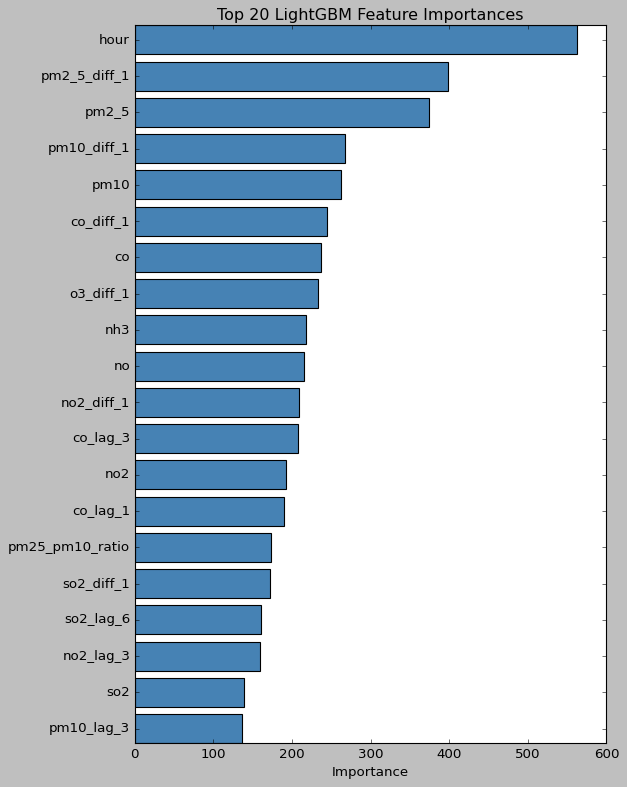

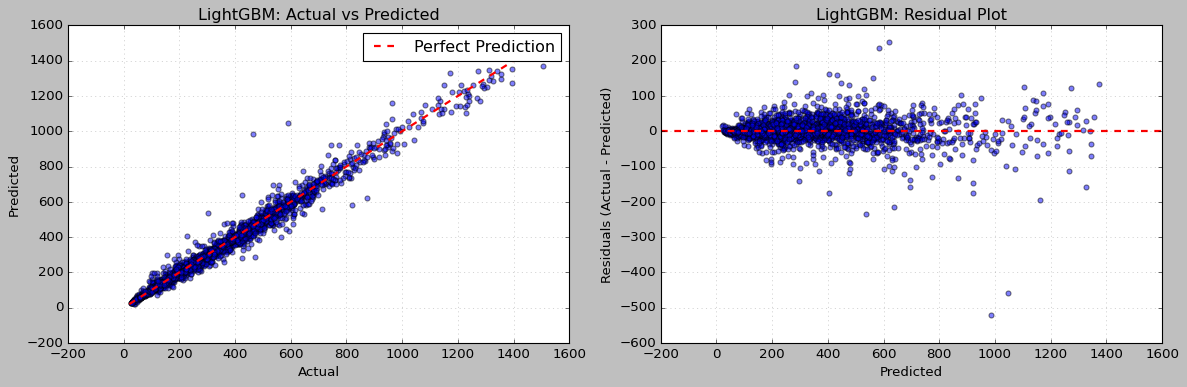

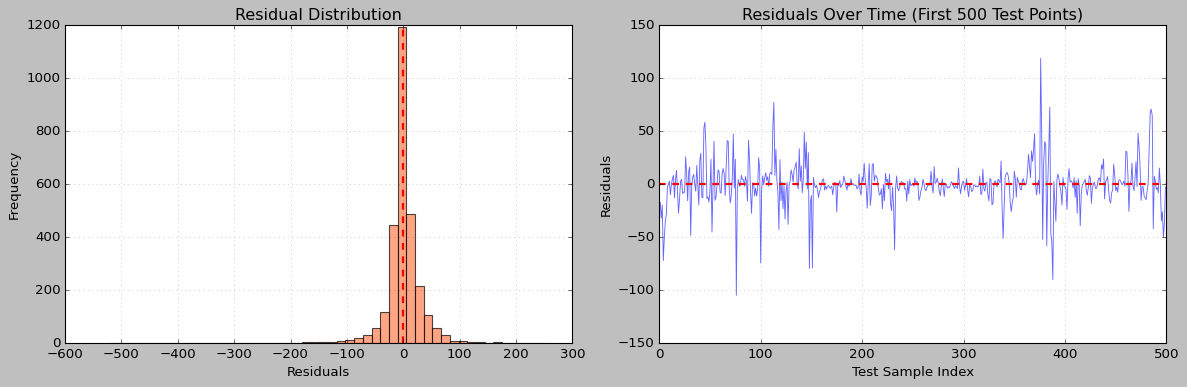

In [ ]:
# Cell 17 — Evaluation + Feature Importance (using final_model)

# LightGBM predictions
lgb_preds = final_model.predict(X_test)

# Metrics
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_mae  = mean_absolute_error(y_test, lgb_preds)
lgb_r2   = r2_score(y_test, lgb_preds)

print("LightGBM Evaluation:")
print("RMSE:", lgb_rmse)
print("MAE :", lgb_mae)
print("R²  :", lgb_r2)

# Feature importance
import matplotlib.pyplot as plt
import pandas as pd

fi = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8,10))
plt.barh(fi["feature"], fi["importance"], color='steelblue')
plt.title("Top 20 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Visualization: Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test, lgb_preds, alpha=0.5, s=20)
min_val = min(y_test.min(), lgb_preds.min())
max_val = max(y_test.max(), lgb_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('LightGBM: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - lgb_preds
axes[1].scatter(lgb_preds, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('LightGBM: Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization: Error distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual Distribution')
axes[0].grid(True, alpha=0.3)

# Prediction error over time (first 500 test points)
n_plot_error = min(500, len(y_test))
axes[1].plot(residuals.values[:n_plot_error], alpha=0.6, linewidth=0.8)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals Over Time (First 500 Test Points)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Cell 18 — Train & evaluate XGBoost (short, compatible)
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib, os

xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)   # no early_stopping_rounds to avoid version issues

xgb_preds = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))
mae_xgb  = mean_absolute_error(y_test, xgb_preds)
r2_xgb   = r2_score(y_test, xgb_preds)

print("XGBoost test results:")
print("RMSE:", rmse_xgb)
print("MAE :", mae_xgb)
print("R²  :", r2_xgb)

os.makedirs('models', exist_ok=True)
joblib.dump(xgb_model, 'models/xgb_model.joblib')
print("Saved XGBoost to models/xgb_model.joblib")


XGBoost test results:
RMSE: 33.32532166592136
MAE : 18.155133177838852
R²  : 0.978959755560801
Saved XGBoost to models/xgb_model.joblib


In [ ]:
# Cell 19 — Model Comparison 

results = pd.DataFrame({
    'model': ['RandomForest', 'XGBoost', 'LightGBM'],
    'rmse': [
        rf_rmse,
        rmse_xgb,         # from XGB cell
        lgb_rmse
    ],
    'mae': [
        rf_mae,
        mae_xgb,          # from XGB cell
        lgb_mae
    ],
    'r2': [
        rf_r2,
        r2_xgb,           # from XGB cell
        lgb_r2
    ]
})

# Visualization: Model comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['rmse', 'mae', 'r2']
metric_names = ['RMSE', 'MAE', 'R²']
colors = ['steelblue', 'coral', 'lightgreen']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    axes[idx].bar(results['model'], results[metric], color=colors[idx], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Model Comparison: {metric_name}')
    axes[idx].set_ylabel(metric_name)
    axes[idx].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(results[metric]):
        axes[idx].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nModel Comparison Summary:")
print(results.to_string(index=False))


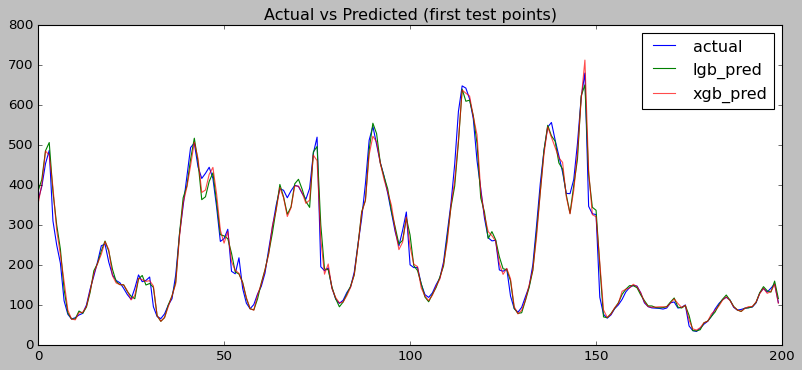

In [ ]:
# Cell 20: Plot prediction vs actual for all models
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: First 200 test points - all models
n_plot = min(200, len(y_test))
axes[0, 0].plot(y_test.values[:n_plot], label='Actual', linewidth=2, color='black')
axes[0, 0].plot(lgb_preds[:n_plot], label='LightGBM', alpha=0.8, linewidth=1.5)
axes[0, 0].plot(xgb_preds[:n_plot], label='XGBoost', alpha=0.7, linewidth=1.5)
rf_preds_plot = rf.predict(X_test.iloc[:n_plot])
axes[0, 0].plot(rf_preds_plot, label='RandomForest', alpha=0.6, linewidth=1.5)
axes[0, 0].set_title('Actual vs Predicted - First 200 Test Points')
axes[0, 0].set_xlabel('Test Sample Index')
axes[0, 0].set_ylabel(f'{target_col.upper()}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Last 200 test points
n_plot_last = min(200, len(y_test))
start_idx = max(0, len(y_test) - n_plot_last)
axes[0, 1].plot(y_test.values[start_idx:], label='Actual', linewidth=2, color='black')
axes[0, 1].plot(lgb_preds[start_idx:], label='LightGBM', alpha=0.8, linewidth=1.5)
axes[0, 1].plot(xgb_preds[start_idx:], label='XGBoost', alpha=0.7, linewidth=1.5)
rf_preds_plot_last = rf.predict(X_test.iloc[start_idx:])
axes[0, 1].plot(rf_preds_plot_last, label='RandomForest', alpha=0.6, linewidth=1.5)
axes[0, 1].set_title('Actual vs Predicted - Last 200 Test Points')
axes[0, 1].set_xlabel('Test Sample Index')
axes[0, 1].set_ylabel(f'{target_col.upper()}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: XGBoost actual vs predicted scatter
axes[1, 0].scatter(y_test, xgb_preds, alpha=0.5, s=20, color='orange')
min_val = min(y_test.min(), xgb_preds.min())
max_val = max(y_test.max(), xgb_preds.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')
axes[1, 0].set_title('XGBoost: Actual vs Predicted')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: RandomForest actual vs predicted scatter
axes[1, 1].scatter(y_test, rf_preds, alpha=0.5, s=20, color='green')
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title('RandomForest: Actual vs Predicted')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Cell 21: (Optional) LSTM baseline - only if you want a deep learning comparison
# This is a simple LSTM using past K hours to predict next hour. It requires scaling and reshaping.
do_lstm = False
if do_lstm:
    from sklearn.preprocessing import StandardScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    # create sequences
    K = 24  # past 24 hours
    X_seq, y_seq = [], []
    for i in range(K, len(X_scaled)):
        X_seq.append(X_scaled[i-K:i])
        y_seq.append(y.iloc[i])
    X_seq = np.array(X_seq); y_seq = np.array(y_seq)
    # train-test split same proportion
    split_idx2 = int(len(X_seq) * 0.85)
    Xtr, Xte = X_seq[:split_idx2], X_seq[split_idx2:]
    ytr, yte = y_seq[:split_idx2], y_seq[split_idx2:]
    model = Sequential()
    model.add(LSTM(64, input_shape=(K, X.shape[1]), return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(Xtr, ytr, epochs=30, batch_size=64, validation_data=(Xte, yte))
    lstm_preds = model.predict(Xte).flatten()
    print("LSTM metrics:", eval_metrics(yte, lstm_preds))


In [ ]:
# Cell 22: Save final best model (LightGBM) and feature list
joblib.dump({'model':'lightgbm', 'model_path':'models/lightgbm_best.joblib', 'features': X.columns.tolist()}, "models/model_metadata.joblib")
print("Saved model metadata and LightGBM model.")


Saved model metadata and LightGBM model.
